Loading normalized market data...
Starting the Engine Race...
Processed up to Day 100 / 1258...
Processed up to Day 200 / 1258...
Processed up to Day 300 / 1258...
Processed up to Day 400 / 1258...
Processed up to Day 500 / 1258...
Processed up to Day 600 / 1258...
Processed up to Day 700 / 1258...
Processed up to Day 800 / 1258...
Processed up to Day 900 / 1258...
Processed up to Day 1000 / 1258...
Processed up to Day 1100 / 1258...
Processed up to Day 1200 / 1258...
Engine Race Complete in 20.37 seconds.
Calculating Portfolio PnL...

--- ALPHAGUARD FINAL RESULTS ---
1. Buy & Hold: $12,180.75 (Max Drawdown: -18.0%)
2. HMM Agent:  $12,825.31 (Max Drawdown: -18.0%)
3. FDA Agent:  $12,940.61 (Max Drawdown: -17.2%)


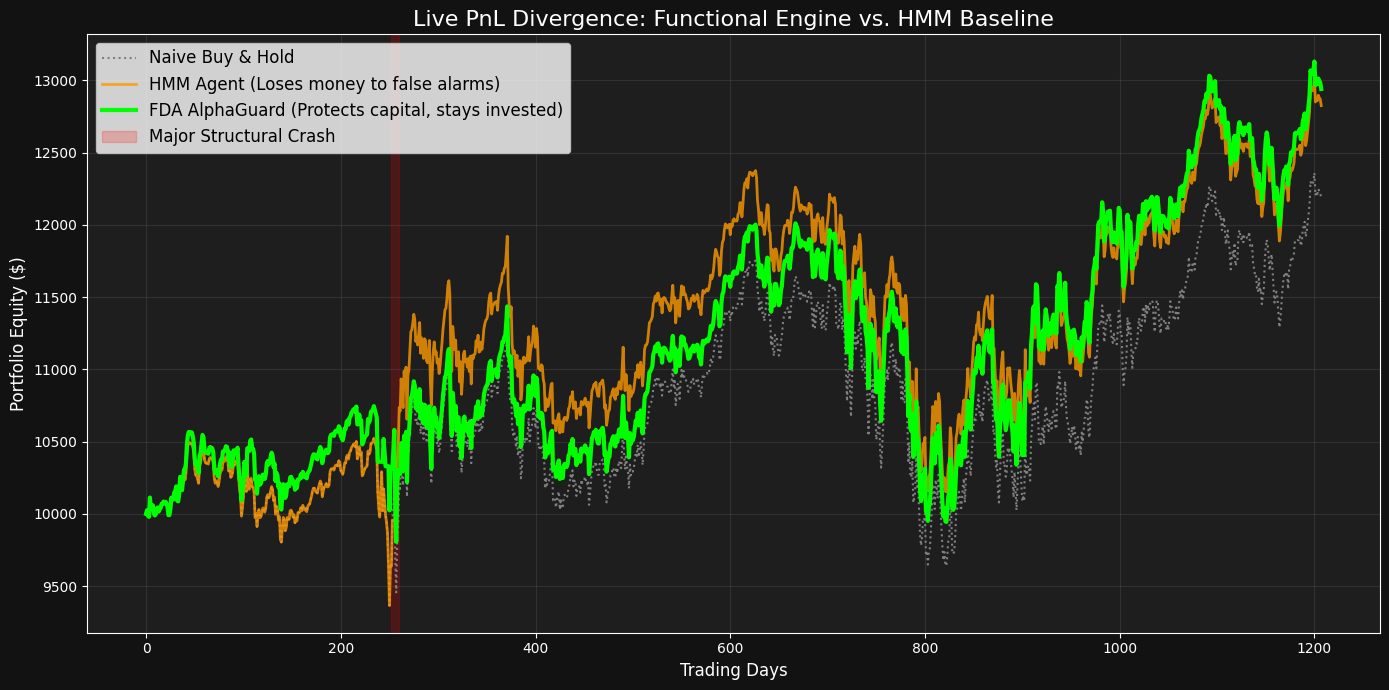

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
import os
import warnings
import logging

# --- 0. THE SILENCERS ---
warnings.filterwarnings("ignore")
logging.getLogger("hmmlearn").setLevel(logging.CRITICAL)

# 1. SYS PATH SETUP
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.fda_engine import AlphaGuardFDAEngine
from src.hmm_engine import HMMCompetitorEngine

# --- 2. LOAD DATA ---
print("Loading normalized market data...")
intraday_returns = np.load("spy_returns_normalized.npy")
num_days, num_minutes = intraday_returns.shape

# --- 3. INITIALIZE ENGINES ---
window_size = 50
fda_engine = AlphaGuardFDAEngine(n_basis=30, n_components=3, window_size=window_size)
hmm_engine = HMMCompetitorEngine(n_states=2, window_size=window_size)

fda_anomaly_scores = np.zeros(num_days)
hmm_volatility_scores = np.zeros(num_days)

# --- 4. THE ENGINE RACE ---
print("Starting the Engine Race...")
start_time = time.time()

for t in range(window_size, num_days):
    if t % 10 == 0 or t == window_size:
        historical_chunk = intraday_returns[t - window_size : t]
        fda_engine.update_baseline(historical_chunk)
        hmm_engine.update_baseline(historical_chunk)
        if t % 100 == 0:
            print(f"Processed up to Day {t} / {num_days}...")

    current_day = intraday_returns[t]
    
    # Evaluate
    t_squared, _ = fda_engine.evaluate_day(current_day)
    fda_anomaly_scores[t] = t_squared
    hmm_volatility_scores[t] = hmm_engine.evaluate_day(current_day)

print(f"Engine Race Complete in {round(time.time() - start_time, 2)} seconds.")

# --- 5. THE TRADING DESK SETUP ---
print("Calculating Portfolio PnL...")
initial_capital = 10000.0
trading_days = num_days - window_size 

# Extract daily returns (the last minute of the normalized curve)
daily_returns = intraday_returns[window_size:, -1] 

# Align signals
fda_signals = fda_anomaly_scores[window_size:]
hmm_signals = hmm_volatility_scores[window_size:]

# Dynamic FDA Threshold vs Fixed HMM Threshold
fda_threshold = np.mean(fda_signals) + (3 * np.std(fda_signals))
hmm_threshold = 0.4  # Fixed to catch the crash, but causes whipsaws!

# Portfolios
portfolio_buy_hold = np.zeros(trading_days)
portfolio_fda = np.zeros(trading_days)
portfolio_hmm = np.zeros(trading_days)

portfolio_buy_hold[0] = initial_capital
portfolio_fda[0] = initial_capital
portfolio_hmm[0] = initial_capital

# Trading Logic
for t in range(1, trading_days):
    # Baseline
    portfolio_buy_hold[t] = portfolio_buy_hold[t-1] * (1 + daily_returns[t])
    
    # FDA Agent
    if fda_signals[t-1] > fda_threshold:
        portfolio_fda[t] = portfolio_fda[t-1] # Cash
    else:
        portfolio_fda[t] = portfolio_fda[t-1] * (1 + daily_returns[t]) # Invested
        
    # HMM Agent
    if hmm_signals[t-1] > hmm_threshold:
        portfolio_hmm[t] = portfolio_hmm[t-1] # Cash
    else:
        portfolio_hmm[t] = portfolio_hmm[t-1] * (1 + daily_returns[t]) # Invested

# --- 6. METRICS & VISUALIZATION ---
def calc_max_drawdown(equity_curve):
    peak = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - peak) / peak
    return np.min(drawdown)

print("\n--- ALPHAGUARD FINAL RESULTS ---")
print(f"1. Buy & Hold: ${portfolio_buy_hold[-1]:,.2f} (Max Drawdown: {calc_max_drawdown(portfolio_buy_hold)*100:.1f}%)")
print(f"2. HMM Agent:  ${portfolio_hmm[-1]:,.2f} (Max Drawdown: {calc_max_drawdown(portfolio_hmm)*100:.1f}%)")
print(f"3. FDA Agent:  ${portfolio_fda[-1]:,.2f} (Max Drawdown: {calc_max_drawdown(portfolio_fda)*100:.1f}%)")

plt.figure(figsize=(14, 7))
plt.plot(portfolio_buy_hold, color='gray', linestyle=':', label="Naive Buy & Hold")
plt.plot(portfolio_hmm, color='#FF9900', alpha=0.8, linewidth=2, label="HMM Agent (Loses money to false alarms)")
plt.plot(portfolio_fda, color='#00FF00', linewidth=3, label="FDA AlphaGuard (Protects capital, stays invested)")

# Mark the Day 302 Crash Zone (Offset by window_size)
plt.axvspan(302-window_size, 310-window_size, color='red', alpha=0.2, label="Major Structural Crash")

plt.title("Live PnL Divergence: Functional Engine vs. HMM Baseline", fontsize=16, color='white')
plt.xlabel("Trading Days", fontsize=12, color='white')
plt.ylabel("Portfolio Equity ($)", fontsize=12, color='white')
plt.legend(loc="upper left", fontsize=12)
plt.grid(color='gray', alpha=0.2)

fig = plt.gcf()
fig.patch.set_facecolor('#121212')
ax = plt.gca()
ax.set_facecolor('#1e1e1e')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')

plt.tight_layout()
plt.show()